In [ ]:
from google.colab import files

uploaded = files.upload()

Saving used_cars.csv to used_cars.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('used_cars.csv')
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [ ]:
df.shape

(4009, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [ ]:
df.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


In [ ]:
df.sample(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
2090,Honda,Passport TrailSport,2023,"11,649 mi.",Gasoline,280.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,9-Speed A/T,Black,Black,NaN,NaN,"$39,999"
1076,Kia,Sorento EX,2016,"64,290 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,6-Speed Automatic,Snow White Pearl,Satin Black,None reported,NaN,"$16,999"
2886,Honda,Odyssey EX-L,2007,"170,000 mi.",Gasoline,244.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Black,Beige,None reported,Yes,"$7,700"
1943,Tesla,Model 3 Standard Range Plus,2019,"42,094 mi.",NaN,Electric Motor Electric Fuel System,A/T,White,White,None reported,Yes,"$32,000"
458,Lexus,ES 350 Base,2008,"146,000 mi.",Gasoline,272.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Red,Beige,None reported,Yes,"$8,995"


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
clean_title,596
fuel_type,170
accident,113
brand,0
milage,0
model_year,0
model,0
engine,0
ext_col,0
transmission,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Clean Numerical Features
# convert milage from 51,000 mi. to 51000

df['milage'] = (
    df['milage']
      .str.replace('mi.', '', regex=False).str.replace(',', '').astype(int)
)

In [ ]:
# convert price from $54,598 to 54598

df['price'] = (
    df['price'].str.replace('$', '', regex=False).str.replace(',', '').astype(float)
)

In [ ]:
df.describe()

,model_year,milage,price
count,4009.000000,4009.000000,4.009000e+03
mean,2015.515590,64717.551010,4.455319e+04
std,6.104816,52296.599459,7.871064e+04
min,1974.000000,100.000000,2.000000e+03
25%,2012.000000,23044.000000,1.720000e+04
50%,2017.000000,52775.000000,3.100000e+04
75%,2020.000000,94100.000000,4.999000e+04
max,2024.000000,405000.000000,2.954083e+06


In [ ]:
df['price']

,price
0,10300.0
1,38005.0
2,54598.0
3,15500.0
4,34999.0
...,...
4004,349950.0
4005,53900.0
4006,90998.0
4007,62999.0


<Axes: xlabel='price', ylabel='Count'>

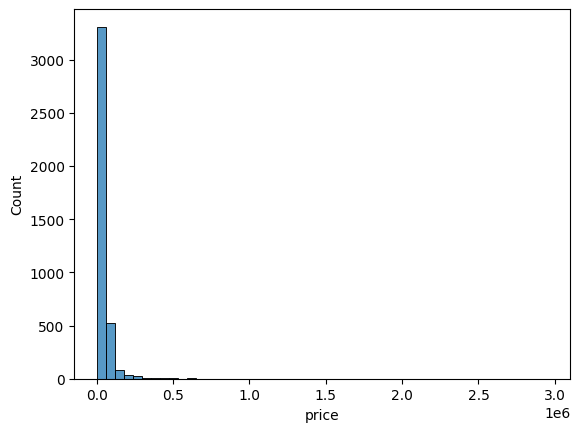

In [ ]:
# histplot
import seaborn as sns

sns.histplot(df['price'], bins=50)

In [ ]:
df['price'].describe()

,price
count,4.009000e+03
mean,4.455319e+04
std,7.871064e+04
min,2.000000e+03
25%,1.720000e+04
50%,3.100000e+04
75%,4.999000e+04
max,2.954083e+06


In [ ]:
# ok so we can observe from statistical data as well as histplot that distribution is right skewed and 50 % of cars have price less than 30,000 and 75 % have price less
# than 50.000 and max price is around 30,00,000.
# Also data distribution for target is highly skewed towards right


(0.0, 700000.0)

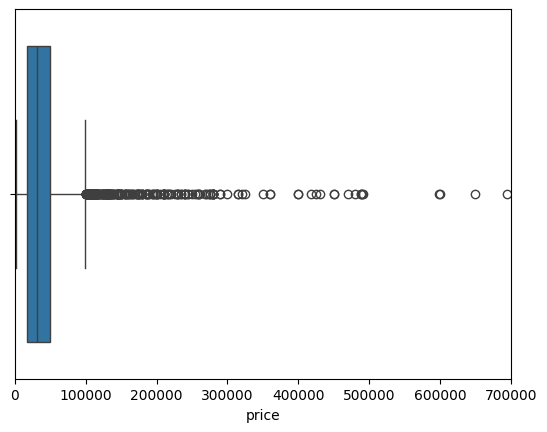

In [ ]:
# box-plot
import matplotlib.pyplot as plt

sns.boxplot(x=df['price'])
plt.xlim(0, 700000)

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 244


In [ ]:
df

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,Continental GT Speed,2023,714,Gasoline,6.0L W12 48V PDI DOHC Twin Turbo,8-Speed Automatic with Auto-Shift,C / C,Hotspur,None reported,Yes,349950.0
4005,Audi,S4 3.0T Premium Plus,2022,10900,Gasoline,349.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,53900.0
4006,Porsche,Taycan,2022,2116,NaN,Electric,Automatic,Black,Black,None reported,NaN,90998.0
4007,Ford,F-150 Raptor,2020,33000,Gasoline,450.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Blue,Black,None reported,Yes,62999.0


In [ ]:
# So out of 4009 we have 244 records as outliers corresponding to price

In [ ]:
# Feature understanding

# brand

df['brand'].nunique()

57

In [ ]:
df['brand'].value_counts()

,count
brand,
Ford,386
BMW,375
Mercedes-Benz,315
Chevrolet,292
Porsche,201
Audi,200
Toyota,199
Lexus,163
Jeep,143


In [ ]:
# fuel_type

df['fuel_type'].value_counts()

,count
fuel_type,
Gasoline,3309
Hybrid,194
E85 Flex Fuel,139
Diesel,116
–,45
Plug-In Hybrid,34
not supported,2


In [ ]:
df['fuel_type'].nunique()

7

In [ ]:
# transmission

df['transmission'].value_counts()

,count
transmission,
A/T,1037
8-Speed A/T,406
Transmission w/Dual Shift Mode,398
6-Speed A/T,362
6-Speed M/T,248
...,...
10-Speed Automatic with Overdrive,1
9-Speed Automatic with Auto-Shift,1
SCHEDULED FOR OR IN PRODUCTION,1


In [ ]:
# accidents

df['accident'].value_counts()

,count
accident,
None reported,2910
At least 1 accident or damage reported,986


In [ ]:
current_year = 2026

df['car_age'] = current_year - df['model_year']

In [ ]:
df.drop('model_year', axis=1, inplace=True)

In [ ]:
df.head()

,brand,model,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age
0,Ford,Utility Police Interceptor Base,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,13
1,Hyundai,Palisade SEL,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,5
2,Lexus,RX 350 RX 350,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598.0,4
3,INFINITI,Q50 Hybrid Sport,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0,11
4,Audi,Q3 45 S line Premium Plus,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,34999.0,5


In [ ]:
df['accident'].isnull().sum()

np.int64(113)

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
clean_title,596
fuel_type,170
accident,113
brand,0
milage,0
model,0
engine,0
transmission,0
int_col,0
ext_col,0


In [ ]:
# Handle Missing Values

df['clean_title'].value_counts(dropna=False)

,count
clean_title,
Yes,3413
NaN,596


In [ ]:
df['clean_title'] = df['clean_title'].fillna('Unknown')

In [ ]:
df['clean_title'].value_counts()

,count
clean_title,
Yes,3413
Unknown,596


In [ ]:
df['accident'].value_counts(dropna=False)

,count
accident,
None reported,2910
At least 1 accident or damage reported,986
NaN,113


In [ ]:
df['accident'] = df['accident'].fillna('Unknown')

In [ ]:
df['accident'].value_counts(dropna=False)

,count
accident,
None reported,2910
At least 1 accident or damage reported,986
Unknown,113


In [ ]:
df['fuel_type'].value_counts(dropna=False)

,count
fuel_type,
Gasoline,3309
Hybrid,194
NaN,170
E85 Flex Fuel,139
Diesel,116
–,45
Plug-In Hybrid,34
not supported,2


In [ ]:
df['fuel_type'] = df['fuel_type'].replace('-', 'Unknown')
df['fuel_type'] = df['fuel_type'].replace('not supported', 'Unknown')
df['fuel_type'] = df['fuel_type'].fillna('Unknown')

In [ ]:
df['fuel_type'].value_counts(dropna=False)

,count
fuel_type,
Gasoline,3309
Hybrid,194
Unknown,172
E85 Flex Fuel,139
Diesel,116
–,45
Plug-In Hybrid,34


In [ ]:
# ok so we were not able to replace minus sign with unknown as that symbol is not there in keyboard

In [ ]:
# Extracting Horsepower

df['engine'].sample(10)

,engine
661,188.0HP 1.6L 4 Cylinder Engine Gasoline Fuel
2195,311.0HP 3.8L V6 Cylinder Engine Gasoline Fuel
1372,5.0L V8 32V GDI DOHC Supercharged
3152,310.0HP 3.0L V6 Cylinder Engine Gasoline Fuel
1069,308.0HP 3.5L V6 Cylinder Engine Gas/Electric H...
3571,3.0L V6 24V GDI DOHC Twin Turbo
3269,265.0HP 2.5L 4 Cylinder Engine Gasoline Fuel
3128,Electric Motor Electric Fuel System
3091,"4L H-6 gasoline direct injection, DOHC, VarioC..."
1920,291.0HP 3.8L V6 Cylinder Engine Gasoline Fuel


In [ ]:
df['horsepower'] = (
    df['engine']
      .str.extract(r'(\d+\.?\d*)HP')[0]
      .astype(float)
)

In [ ]:
df[['engine','horsepower']].head(10)

,engine,horsepower
0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,300.0
1,3.8L V6 24V GDI DOHC,NaN
2,3.5 Liter DOHC,NaN
3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,354.0
4,2.0L I4 16V GDI DOHC Turbo,NaN
5,2.4 Liter,NaN
6,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,292.0
7,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,282.0
8,311.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,311.0
9,534.0HP Electric Motor Electric Fuel System,534.0


In [ ]:
df['horsepower'].isnull().sum()

np.int64(808)

In [ ]:
# filling missing value for horse power with median

df['horsepower'] = df['horsepower'].fillna(
    df['horsepower'].median()
)

In [ ]:
df['horsepower'].isnull().sum()

np.int64(0)

In [ ]:
# Extract Engine Size

df['engine_size'] = (
    df['engine']
      .str.extract(r'(\d+\.?\d*)L')[0]
      .astype(float)
)

In [ ]:
df[['engine','engine_size']].head()

,engine,engine_size
0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,3.7
1,3.8L V6 24V GDI DOHC,3.8
2,3.5 Liter DOHC,NaN
3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,3.5
4,2.0L I4 16V GDI DOHC Turbo,2.0


In [ ]:
df['engine_size'].isnull().sum()

np.int64(377)

In [ ]:
df['engine_size'] = df['engine_size'].fillna(
    df['engine_size'].median()
)

In [ ]:
df['engine_size'].isnull().sum()

np.int64(0)

In [ ]:
df['model'].nunique()

1898

In [ ]:
# So 1898 is a very big number so we can't do one hot encoding instead of that we can select the top 50 models and then name rest of them as "Other".

In [ ]:
top_models = df['model'].value_counts().nlargest(50).index

In [ ]:
df['model_grouped'] = np.where(df['model'].isin(top_models), df['model'], 'Other')

In [ ]:
len(df['model_grouped'].value_counts())

51

In [ ]:
# Drop columns that are not that useful (feature selection -> select the most imp columns)

df.drop(
    columns=[
        'engine',
        'ext_col',
        'int_col'
    ],
    inplace=True
)

In [ ]:
df.sample(10)

,brand,model,milage,fuel_type,transmission,accident,clean_title,price,car_age,horsepower,engine_size,model_grouped
3339,Toyota,Highlander Limited,106000,Gasoline,5-Speed A/T,At least 1 accident or damage reported,Yes,16600.0,15,270.0,3.5,Other
125,Chevrolet,Express 1500 Work Van,93009,E85 Flex Fuel,4-Speed Automatic,None reported,Yes,22495.0,15,310.0,5.3,Other
1146,Nissan,Frontier SL,103400,Gasoline,5-Speed A/T,At least 1 accident or damage reported,Yes,17000.0,15,261.0,4.0,Other
3249,MINI,Cooper S Base,99600,Gasoline,6-Speed A/T,None reported,Yes,5500.0,20,168.0,1.6,Cooper S Base
221,Volkswagen,Golf GTI 2.0T S 4-Door,89000,Gasoline,6-Speed M/T,None reported,Yes,14500.0,10,210.0,2.0,Other
2233,Rivian,R1T Launch Edition,8681,Unknown,A/T,None reported,Yes,82000.0,4,835.0,3.5,Other
2507,Audi,A3 2.0T Premium,137000,Gasoline,7-Speed A/T,None reported,Yes,10995.0,9,186.0,2.0,Other
2431,Acura,TL Technology,89190,Gasoline,6-Speed A/T,At least 1 accident or damage reported,Yes,15499.0,13,305.0,3.7,Other
529,Tesla,Model Y Long Range,69548,Unknown,1-Speed A/T,At least 1 accident or damage reported,Yes,36300.0,5,425.0,3.5,Model Y Long Range
3084,Toyota,Corolla S Plus,68364,Gasoline,Transmission w/Dual Shift Mode,None reported,Yes,16000.0,10,132.0,1.8,Other


In [ ]:
df['log_price'] = np.log1p(df['price'])

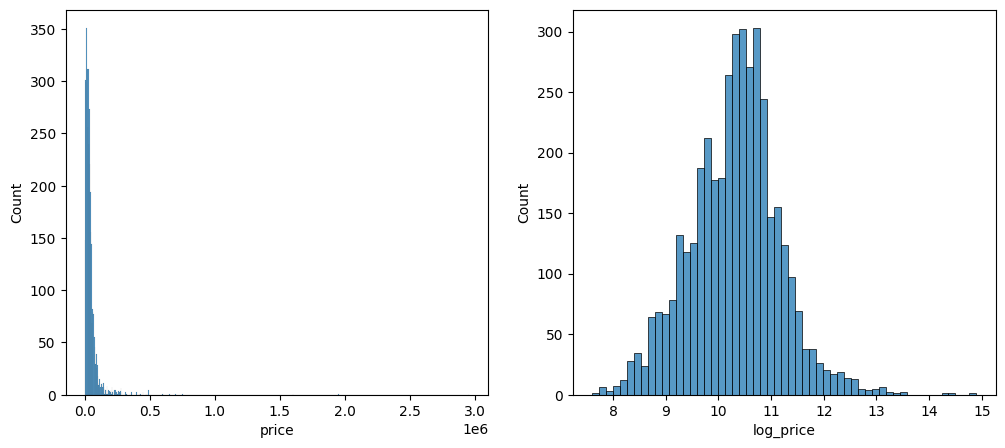

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['price'])

plt.subplot(1,2,2)
sns.histplot(df['log_price'])

plt.show()

<Axes: xlabel='log_price', ylabel='Density'>

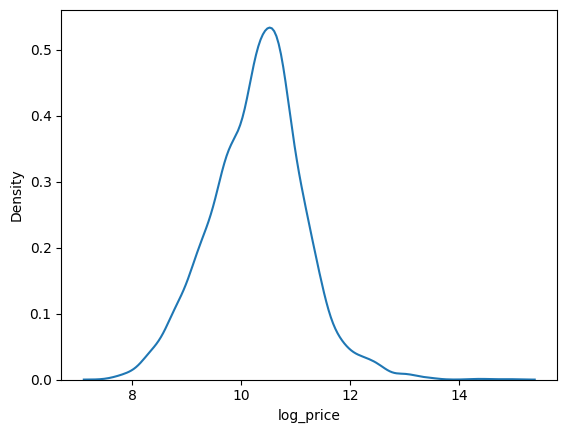

In [ ]:
sns.kdeplot(df['log_price'])

In [ ]:
# So we can see that log_price has much more normal-looking distribution.

In [ ]:
num_cols = [
    'price',
    'milage',
    'car_age',
    'horsepower',
    'engine_size'
]

corr = df[num_cols].corr()

corr

,price,milage,car_age,horsepower,engine_size
price,1.000000,-0.305528,-0.199496,0.267426,0.173865
milage,-0.305528,1.000000,0.617720,-0.293725,0.063682
car_age,-0.199496,0.617720,1.000000,-0.239563,0.101035
horsepower,0.267426,-0.293725,-0.239563,1.000000,0.525846
engine_size,0.173865,0.063682,0.101035,0.525846,1.000000


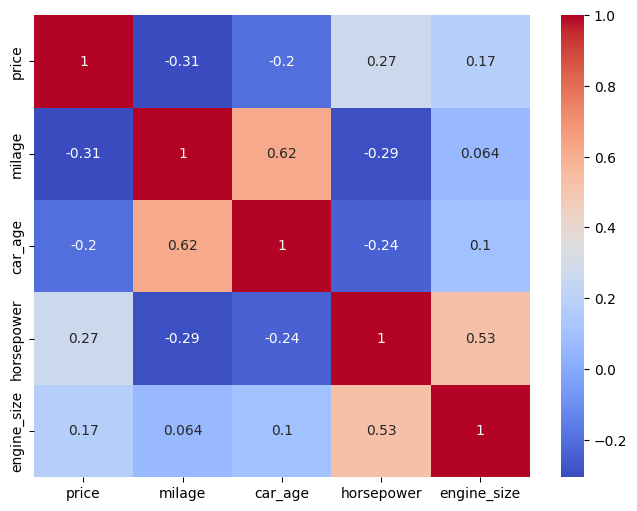

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr, annot=True, cmap='coolwarm'
)

plt.show()

In [ ]:
X = df.drop(
    columns=[
        'price',
        'log_price',
        'model'
    ]
)

y = df['log_price']

In [ ]:
X

,brand,milage,fuel_type,transmission,accident,clean_title,car_age,horsepower,engine_size,model_grouped
0,Ford,51000,E85 Flex Fuel,6-Speed A/T,At least 1 accident or damage reported,Yes,13,300.0,3.7,Other
1,Hyundai,34742,Gasoline,8-Speed Automatic,At least 1 accident or damage reported,Yes,5,310.0,3.8,Other
2,Lexus,22372,Gasoline,Automatic,None reported,Unknown,4,310.0,3.5,Other
3,INFINITI,88900,Hybrid,7-Speed A/T,None reported,Yes,11,354.0,3.5,Other
4,Audi,9835,Gasoline,8-Speed Automatic,None reported,Unknown,5,310.0,2.0,Other
...,...,...,...,...,...,...,...,...,...,...
4004,Bentley,714,Gasoline,8-Speed Automatic with Auto-Shift,None reported,Yes,3,310.0,6.0,Other
4005,Audi,10900,Gasoline,Transmission w/Dual Shift Mode,None reported,Yes,4,349.0,3.0,Other
4006,Porsche,2116,Unknown,Automatic,None reported,Unknown,4,310.0,3.5,Other
4007,Ford,33000,Gasoline,A/T,None reported,Yes,6,450.0,3.5,Other


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   brand          4009 non-null   object 
 1   milage         4009 non-null   int64  
 2   fuel_type      4009 non-null   object 
 3   transmission   4009 non-null   object 
 4   accident       4009 non-null   object 
 5   clean_title    4009 non-null   object 
 6   car_age        4009 non-null   int64  
 7   horsepower     4009 non-null   float64
 8   engine_size    4009 non-null   float64
 9   model_grouped  4009 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 313.3+ KB


In [ ]:
categorical_cols = X.select_dtypes(
    include='object'
).columns.tolist()

numerical_cols = X.select_dtypes(
    exclude='object'
).columns.tolist()

print(categorical_cols)
print(numerical_cols)

['brand', 'fuel_type', 'transmission', 'accident', 'clean_title', 'model_grouped']
['milage', 'car_age', 'horsepower', 'engine_size']


In [ ]:
X.sample(5)

,brand,milage,fuel_type,transmission,accident,clean_title,car_age,horsepower,engine_size,model_grouped
146,Hyundai,654,Gasoline,8-Speed Automatic with Auto-Shift,None reported,Yes,3,310.0,2.0,Other
152,Ferrari,19987,Gasoline,7-Speed A/T,None reported,Yes,10,651.0,6.3,Other
854,Ford,81000,Gasoline,10-Speed A/T,None reported,Yes,7,375.0,3.5,F-150 Lariat
2707,Hyundai,5100,Gasoline,A/T,None reported,Yes,4,120.0,1.6,Other
757,Rivian,2108,Unknown,1-Speed A/T,None reported,Yes,3,835.0,3.5,R1S Adventure Package


In [ ]:
# Train-Test-Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3207, 10)
(802, 10)


In [ ]:
# preprocesing pipeline

preprocessor = ColumnTransformer(
    transformers = [
      (
          'num',
          StandardScaler(),
          numerical_cols
      ),
      (
          'cat',
          OneHotEncoder(
              handle_unknown='ignore'
          ),
          categorical_cols
      )
    ]
)

In [ ]:
# Linear regression

lr_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [ ]:
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['milage', 'car_age',
                                                   'horsepower',
                                                   'engine_size']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'fuel_type',
                                                   'transmission', 'accident',
                                                   'clean_title',
                                                   'model_grouped'])])),
                ('model', LinearRegression())])

In [ ]:
y_pred = lr_pipeline.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

lr_r2 = r2_score(y_test,y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", lr_r2)

MAE : 0.24913543853252873
RMSE: 0.4068768138909791
R2  : 0.7873987763641417


In [ ]:
lr_pipeline.named_steps

{'preprocessor': ColumnTransformer(transformers=[('num', StandardScaler(),
                                  ['milage', 'car_age', 'horsepower',
                                   'engine_size']),
                                 ('cat', OneHotEncoder(handle_unknown='ignore'),
                                  ['brand', 'fuel_type', 'transmission',
                                   'accident', 'clean_title',
                                   'model_grouped'])]),
 'model': LinearRegression()}

In [ ]:
ohe = lr_pipeline.named_steps['preprocessor'].named_transformers_['cat']

In [ ]:
ohe.categories_

[array(['Acura', 'Alfa', 'Aston', 'Audi', 'BMW', 'Bentley', 'Buick',
        'Cadillac', 'Chevrolet', 'Chrysler', 'Dodge', 'FIAT', 'Ferrari',
        'Ford', 'GMC', 'Genesis', 'Honda', 'Hummer', 'Hyundai', 'INFINITI',
        'Jaguar', 'Jeep', 'Karma', 'Kia', 'Lamborghini', 'Land', 'Lexus',
        'Lincoln', 'Lotus', 'Lucid', 'MINI', 'Maserati', 'Maybach',
        'Mazda', 'McLaren', 'Mercedes-Benz', 'Mercury', 'Mitsubishi',
        'Nissan', 'Plymouth', 'Polestar', 'Pontiac', 'Porsche', 'RAM',
        'Rivian', 'Rolls-Royce', 'Saab', 'Saturn', 'Scion', 'Subaru',
        'Suzuki', 'Tesla', 'Toyota', 'Volkswagen', 'Volvo', 'smart'],
       dtype=object),
 array(['Diesel', 'E85 Flex Fuel', 'Gasoline', 'Hybrid', 'Plug-In Hybrid',
        'Unknown', '–'], dtype=object),
 array(['1-Speed A/T', '1-Speed Automatic', '10-Speed A/T',
        '10-Speed Automatic', '10-Speed Automatic with Overdrive', '2',
        '2-Speed A/T', '2-Speed Automatic', '4-Speed A/T',
        '4-Speed Automatic', '5

In [ ]:
# Convert Predictions Back to Price

actual_price = np.expm1(y_test)

predicted_price = np.expm1(y_pred)

In [ ]:
comparison = pd.DataFrame({
    'Actual': actual_price,
    'Predicted': predicted_price
})

comparison.head(20)

,Actual,Predicted
2580,28000.0,32211.103706
3660,5900.0,9766.716797
897,41000.0,45780.324335
2091,40250.0,44413.088068
1044,77999.0,66857.595267
2320,35899.0,29935.987382
465,36000.0,31595.429422
196,47214.0,53476.351716
3113,30900.0,15093.239840
3553,11000.0,11919.358317


In [ ]:
# Residual Analysis

residuals = y_test - y_pred

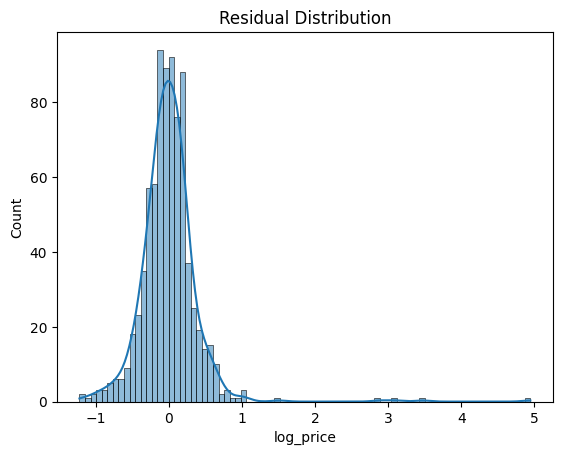

In [ ]:
sns.histplot(residuals, kde=True)

plt.title('Residual Distribution')
plt.show()

In [ ]:
df3 = pd.DataFrame(residuals)
df3.describe()

,log_price
count,802.000000
mean,0.001520
std,0.407128
min,-1.219934
25%,-0.183675
50%,-0.011139
75%,0.170280
max,4.945701


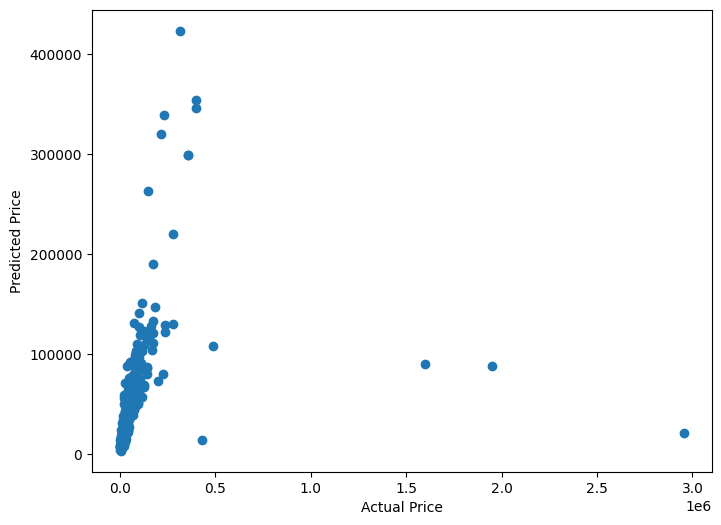

In [ ]:
# Actual vs Predicted Plot

plt.figure(figsize=(8,6))

plt.scatter(
    actual_price,
    predicted_price
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

In [ ]:
# Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor

dt_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            DecisionTreeRegressor(
                max_depth=8,
                random_state=42
            )
        )
    ]
)

In [ ]:
dt_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['milage', 'car_age',
                                                   'horsepower',
                                                   'engine_size']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'fuel_type',
                                                   'transmission', 'accident',
                                                   'clean_title',
                                                   'model_grouped'])])),
                ('model', DecisionTreeRegressor(max_depth=8, random_state=42))])

In [ ]:
dt_pred = dt_pipeline.predict(X_test)
dt_r2 = r2_score(y_test, dt_pred)

In [ ]:
print("R2:", r2_score(y_test,dt_pred))

R2: 0.7264972704912737


In [ ]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

In [ ]:
rf_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['milage', 'car_age',
                                                   'horsepower',
                                                   'engine_size']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'fuel_type',
                                                   'transmission', 'accident',
                                                   'clean_title',
                                                   'model_grouped'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [ ]:
rf_pred = rf_pipeline.predict(X_test)

In [ ]:
rf_r2 = r2_score(y_test,rf_pred)

rf_mse = mean_squared_error(y_test,rf_pred)

rf_rmse = np.sqrt(rf_mse)

print("R2:", rf_r2)
print("RMSE:", rf_rmse)

R2: 0.8218465261320267
RMSE: 0.3724579166841713


In [ ]:
# Comparison b/w all 3 models

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'R2 Score': [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,R2 Score
2,Random Forest,0.821847
0,Linear Regression,0.787399
1,Decision Tree,0.726497
